# Starter notebook: Breast Cancer AI Challenge

This notebook trains two simple baseline models and writes `submission.csv` in the competition format.
Run it once to see a valid submission, then replace the baselines with your own models.

**Stage 1, Detection:** from a breast ultrasound image, predict normal, benign or malignant and outline the lesion.
**Stage 2, Evolution:** from clinical data and gene expression, predict risk and 3 and 5 year survival.

**Rules of thumb for your final notebook**

* It must run with the internet off.
* Fit everything (scalers, gene lists, thresholds) on the training data only.
* Predict each image or patient on its own, so the result does not depend on the other test samples.

In [1]:
import glob, json, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
SEED = 2026
np.random.seed(SEED)


def find_bundle_dirs():
    """(train_dir, test_dir): env vars first, then a bundle marked 'final', else 'development'."""
    env_train, env_test = os.environ.get("BCPIPE_TRAIN_DIR"), os.environ.get("BCPIPE_TEST_DIR")
    found = {}
    roots = [Path(os.environ["BCPIPE_DATA"])] if os.environ.get("BCPIPE_DATA") else []
    roots.append(Path("/kaggle/input"))
    for root in roots:
        for depth in range(1, 6):
            for p in sorted(glob.glob(str(root.joinpath(*(["*"] * (depth - 1)), "BUNDLE_INFO.json")))):
                found.setdefault(json.loads(Path(p).read_text()).get("bundle"), Path(p).parent)
    dev = found.get("development")
    test = Path(env_test) if env_test else (found.get("final") or dev)
    train = Path(env_train) if env_train else (dev.parent / "train" if dev else None)
    if test is None or train is None:
        raise FileNotFoundError("Competition data not found: attach the competition dataset.")
    return train, test


TRAIN_DIR, TEST_DIR = find_bundle_dirs()
OUTPUT = Path(os.environ.get("BCPIPE_OUTPUT",
              "/kaggle/working/submission.csv" if Path("/kaggle/working").exists() else "submission.csv"))
INFO = json.loads((TEST_DIR / "BUNDLE_INFO.json").read_text())
print("train:", TRAIN_DIR, "| test:", TEST_DIR, "| bundle:", INFO.get("bundle"), INFO.get("stages"))
predictions = {}  # row_id -> prediction

train: /kaggle/input/competitions/skillntell-breast-cancer-v2/train | test: /kaggle/input/competitions/skillntell-breast-cancer-v2/test | bundle: development ['S1', 'S3']


In [2]:
def rle_encode(mask):
    """Row-major order, 1-indexed starts: 'start length start length ...'; a single space for an empty mask (Kaggle rejects empty cells)."""
    flat = np.asarray(mask, bool).ravel(order="C").astype(np.int8)
    if not flat.any():
        return " "
    padded = np.concatenate([[0], flat, [0]])
    ch = np.flatnonzero(padded[1:] != padded[:-1]) + 1
    return " ".join(f"{s} {e - s}" for s, e in zip(ch[0::2], ch[1::2]))


def harrell_c(time, event, risk):
    """Quick CV feedback only (the official metric uses Uno's C, time-dependent AUROC and Brier)."""
    time, event, risk = map(np.asarray, (time, event, risk))
    ev = np.flatnonzero(event == 1)
    comparable = time[None, :] > time[ev][:, None]
    diff = risk[ev][:, None] - risk[None, :]
    return (((diff > 0) & comparable).sum() + 0.5 * ((diff == 0) & comparable).sum()) / comparable.sum()

## Stage 1: Detection (ultrasound)

Predict normal, benign or malignant, plus a lesion mask.

Baseline: a few simple image features, then a basic classifier, and a simple guess for the mask.

In [3]:
from PIL import Image
from scipy import ndimage
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CLASSES = ["normal", "benign", "malignant"]
S1_TRAIN, S1_TEST = TRAIN_DIR / "stage1", TEST_DIR / "stage1"


def us_features(path, size=64):
    a = np.asarray(Image.open(path).convert("L").resize((size, size), Image.BILINEAR), np.float32) / 255.0
    hist = np.histogram(a, bins=16, range=(0, 1))[0] / a.size
    return np.concatenate([a.ravel(), hist, [a.mean(), a.std()]])


def lesion_mask(path, p_lesion, threshold=0.5):
    a = np.asarray(Image.open(path).convert("L"), np.float32)
    if p_lesion < threshold:
        return np.zeros(a.shape, bool)
    sm = ndimage.gaussian_filter(a, 3)
    h, w = a.shape
    centre = np.zeros(a.shape, bool)
    centre[h // 6: 5 * h // 6, w // 6: 5 * w // 6] = True
    cand = (sm <= np.percentile(sm[centre], 12)) & centre
    lab, n = ndimage.label(cand)
    if n == 0:
        return np.zeros(a.shape, bool)
    sizes = ndimage.sum(cand, lab, range(1, n + 1))
    m = lab == (1 + int(np.argmax(sizes)))
    return ndimage.binary_fill_holes(ndimage.binary_closing(m, iterations=3))


def make_s1():
    return make_pipeline(StandardScaler(), PCA(n_components=40, random_state=SEED),
                         LogisticRegression(C=0.05, max_iter=3000))


s1 = pd.read_csv(S1_TRAIN / "train.csv")
X1 = np.stack([us_features(S1_TRAIN / "images" / f"{i}.png") for i in s1.image_id])
y1 = s1.label.map({c: k for k, c in enumerate(CLASSES)}).to_numpy()
oof1 = np.zeros((len(s1), 3))
for f in sorted(s1.fold.unique()):
    va = s1.fold.to_numpy() == f
    oof1[va] = make_s1().fit(X1[~va], y1[~va]).predict_proba(X1[va])
dice_cv = []
for i, image_id in enumerate(s1.image_id):
    gt = np.asarray(Image.open(S1_TRAIN / "masks" / f"{image_id}.png")) > 0
    pr = lesion_mask(S1_TRAIN / "images" / f"{image_id}.png", 1 - oof1[i, 0])
    dice_cv.append(1.0 if gt.sum() + pr.sum() == 0 else 2 * (gt & pr).sum() / (gt.sum() + pr.sum()))
auc1 = np.mean([roc_auc_score(y1 == k, oof1[:, k]) for k in range(3)])
print(f"Stage 1 grouped-CV: macro AUROC {auc1:.3f} | mean Dice {np.mean(dice_cv):.3f}")
model_s1 = make_s1().fit(X1, y1)

if (S1_TEST / "images.csv").exists():
    t1 = pd.read_csv(S1_TEST / "images.csv")
    P1 = model_s1.predict_proba(np.stack([us_features(S1_TEST / "images" / f"{i}.png") for i in t1.image_id]))
    for image_id, p in zip(t1.image_id, P1):
        for k, c in enumerate(CLASSES):
            predictions[f"S1_{image_id}_{c}"] = float(p[k])
        predictions[f"S1_{image_id}_mask"] = rle_encode(lesion_mask(S1_TEST / "images" / f"{image_id}.png", 1 - p[0]))
    print(f"Stage 1: predicted {len(t1)} test images")

Stage 1 grouped-CV: macro AUROC 0.715 | mean Dice 0.096
Stage 1: predicted 256 test images


## Stage 2: Evolution (survival)

Predict a risk score and the chance of surviving 3 and 5 years. Rows of this stage start with `S3_`.

Baseline: a simple survival model on the clinical data plus a few summary values of the gene expression.

In [4]:
from scipy.optimize import minimize

S3_TRAIN, S3_TEST = TRAIN_DIR / "stage3", TEST_DIR / "stage3"
CAT = {"t_cat": ["T1", "T2", "T3", "T4", "unknown"], "n_cat": ["N0", "N1", "N2", "N3", "unknown"],
       "histology": ["ductal", "lobular", "mixed", "other", "unknown"], "menopause": ["pre", "post", "unknown"]}


def clinical_matrix(df, stats=None):
    out = pd.DataFrame(index=df.index)
    out["age"] = df["age"]
    for c in ("er", "pr", "her2"):
        out[c] = df[c]
    for c, levels in CAT.items():
        for level in levels[:-1]:
            out[f"{c}_{level}"] = (df[c].astype(str) == level).astype(float)
    if stats is None:
        stats = {"mean": out.mean(), "std": out.std().replace(0, 1).fillna(1)}
    out = out.fillna(stats["mean"])
    return ((out - stats["mean"]) / stats["std"]).to_numpy(float), stats


def fit_cox(X, time, event, l2=1.0):
    order = np.argsort(time, kind="mergesort")
    X, time, event = X[order], time[order], event[order]
    first = np.searchsorted(time, time, side="left")  # risk set = all with time >= t_i (ties included)

    def nll(beta):
        eta = X @ beta
        w = np.exp(eta - eta.max())
        rs = np.cumsum(w[::-1])[::-1][first]
        rsx = np.cumsum((w[:, None] * X)[::-1], axis=0)[::-1][first]
        ll = np.sum(event * (eta - eta.max() - np.log(rs)))
        grad = -(event[:, None] * (X - rsx / rs[:, None])).sum(0) + l2 * beta
        return -ll + 0.5 * l2 * beta @ beta, grad

    beta = minimize(nll, np.zeros(X.shape[1]), jac=True, method="L-BFGS-B").x
    w = np.exp(X @ beta)
    rs = np.cumsum(w[::-1])[::-1][first]
    return beta, time[event == 1], 1.0 / rs[event == 1]


def predict_cox(model, X, horizons=(3.0, 5.0)):
    beta, ev_t, ev_h = model
    risk = X @ beta
    return risk, [np.exp(-ev_h[ev_t <= t].sum() * np.exp(risk)) for t in horizons]


def stage3_features(clin, expr, state=None):
    if state is None:
        _, cstats = clinical_matrix(clin)
        pca = PCA(n_components=10, random_state=SEED).fit(expr.to_numpy())
        Z = pca.transform(expr.to_numpy())
        state = (cstats, pca, Z.mean(0), Z.std(0) + 1e-9)
    cstats, pca, zm, zs = state
    Xc, _ = clinical_matrix(clin, cstats)
    return np.hstack([Xc, (pca.transform(expr.to_numpy()) - zm) / zs]), state


clin_tr = pd.read_csv(S3_TRAIN / "clinical.csv").set_index("patient_id")
surv_tr = pd.read_csv(S3_TRAIN / "survival.csv").set_index("patient_id").loc[clin_tr.index]
expr_tr = pd.read_parquet(S3_TRAIN / "expression_ranks.parquet").set_index("patient_id").loc[clin_tr.index]
ok = (surv_tr["dss_time"] > 0) & surv_tr["dss_event"].notna()
clin_tr, surv_tr, expr_tr = clin_tr[ok], surv_tr[ok], expr_tr[ok]
GENES = list(expr_tr.columns)
T3, D3, F3 = surv_tr["dss_time"].to_numpy(), surv_tr["dss_event"].to_numpy().astype(int), clin_tr["fold"].to_numpy()
oof3 = np.zeros(len(T3))
for f in np.unique(F3):
    va = F3 == f
    Xa, st = stage3_features(clin_tr[~va], expr_tr[~va])
    Xb, _ = stage3_features(clin_tr[va], expr_tr[va], st)
    oof3[va] = predict_cox(fit_cox(Xa, T3[~va], D3[~va]), Xb)[0]
print(f"Stage 2 (Evolution) site-grouped CV: Harrell C (DSS) {harrell_c(T3, D3, oof3):.3f} (n={len(T3)}, events={D3.sum()})")
X3, state3 = stage3_features(clin_tr, expr_tr)
model_s3 = fit_cox(X3, T3, D3)

if (S3_TEST / "clinical.csv").exists():
    clin_te = pd.read_csv(S3_TEST / "clinical.csv").set_index("patient_id")
    expr_te = pd.read_parquet(S3_TEST / "expression_ranks.parquet").set_index("patient_id").loc[clin_te.index, GENES]
    X_te, _ = stage3_features(clin_te, expr_te, state3)
    risk, (s3y, s5y) = predict_cox(model_s3, X_te)
    for pid, r, a, b in zip(clin_te.index, risk, s3y, s5y):
        predictions[f"S3_{pid}_risk"] = float(r)
        predictions[f"S3_{pid}_surv3y"] = float(a)
        predictions[f"S3_{pid}_surv5y"] = float(b)
    print(f"Stage 2 (Evolution): predicted {len(clin_te)} test patients")

Stage 2 (Evolution) site-grouped CV: Harrell C (DSS) 0.689 (n=837, events=74)
Stage 2 (Evolution): predicted 211 test patients


## Write the submission

In [5]:
sample = pd.read_csv(TEST_DIR / "sample_submission.csv")
missing = [r for r in sample.row_id if r not in predictions]
if missing:
    print(f"WARNING: {len(missing)} rows not predicted, sample defaults kept (e.g. {missing[:3]})")
submission = sample.copy()
submission["prediction"] = [predictions.get(r, d) for r, d in zip(sample.row_id, sample.prediction)]
submission.to_csv(OUTPUT, index=False)
print("wrote", OUTPUT, submission.shape)
submission.head(12)

wrote /kaggle/working/submission.csv (1657, 2)


,row_id,prediction
0,S1_US316340_normal,0.084966
1,S1_US316340_benign,0.889527
2,S1_US316340_malignant,0.025508
3,S1_US316340_mask,43387 160 43873 158 44358 153 44843 152 45329 ...
4,S1_USb5e95b_normal,0.09836
5,S1_USb5e95b_benign,0.767807
6,S1_USb5e95b_malignant,0.133833
7,S1_USb5e95b_mask,154077 5 154834 14 154863 12 155593 47 156352 ...
8,S1_US7de6f6_normal,0.236971
9,S1_US7de6f6_benign,0.666876


## Where to go next

* **Stage 1:** try a stronger image model, and a better way to outline the lesion.
* **Stage 2:** try more genes or a different survival model, and keep your survival probabilities honest.
* **Before the deadline:** make one final notebook that runs by itself, and read the Rules.

In [6]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if any(word in file.lower() for word in ["mask", "seg"]):
            print(os.path.join(root, file))

In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)

    if level <= 3:
        print(f"\n📁 {root}")
        for d in dirs[:10]:
            print(f"   [DIR]  {d}")
        for f in files[:10]:
            print(f"   [FILE] {f}")


📁 /kaggle/input
   [DIR]  competitions

📁 /kaggle/input/competitions
   [DIR]  skillntell-breast-cancer-v2

📁 /kaggle/input/competitions/skillntell-breast-cancer-v2
   [DIR]  test
   [DIR]  train
   [FILE] sample_submission.csv

📁 /kaggle/input/competitions/skillntell-breast-cancer-v2/test
   [DIR]  stage1
   [DIR]  stage3
   [FILE] sample_submission.csv
   [FILE] BUNDLE_INFO.json

📁 /kaggle/input/competitions/skillntell-breast-cancer-v2/train
   [DIR]  stage1
   [DIR]  stage3


In [8]:
import os

base = "/kaggle/input/competitions/skillntell-breast-cancer-v2/train/stage1"

for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")

    for file in files[:10]:
        path = os.path.join(root, file)
        print("  " * (level + 1) + f"{file} ({os.path.getsize(path):,} bytes)")

    if level >= 2:
        dirs[:] = []

stage1/
  train.csv (25,943 bytes)
  images/
    USe536be.png (183,588 bytes)
    US85f744.png (186,846 bytes)
    USf150c5.png (132,376 bytes)
    USf71f2f.png (148,129 bytes)
    USe8762b.png (95,817 bytes)
    US993a35.png (108,443 bytes)
    USecd938.png (120,275 bytes)
    US29ff42.png (121,581 bytes)
    USca54e7.png (116,151 bytes)
    USd2d864.png (128,152 bytes)
  masks/
    USe536be.png (1,772 bytes)
    US85f744.png (536 bytes)
    USf150c5.png (753 bytes)
    USf71f2f.png (1,549 bytes)
    USe8762b.png (743 bytes)
    US993a35.png (1,043 bytes)
    USecd938.png (1,332 bytes)
    US29ff42.png (546 bytes)
    USca54e7.png (701 bytes)
    USd2d864.png (777 bytes)


Columns: ['image_id', 'label', 'height', 'width', 'dup_group', 'fold']
   image_id   label  height  width dup_group  fold
0  USa1d76c  benign     471    562     G0000     1
1  US020ca5  benign     585    683     G0001     3
2  US2603c7  benign     473    323     G0002     1
3  US62c932  benign     473    563     G0003     3
4  US48ee0f  benign     610    634     G0004     0


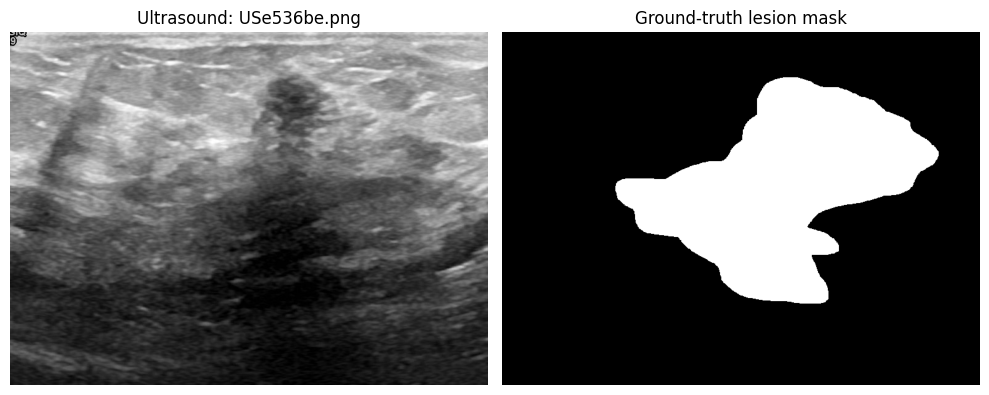

Image size: (776, 574)
Mask size: (776, 574)
Unique mask values: [0, 255]


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

base = "/kaggle/input/competitions/skillntell-breast-cancer-v2/train/stage1"

df = pd.read_csv(os.path.join(base, "train.csv"))
print("Columns:", df.columns.tolist())
print(df.head())

image_dir = os.path.join(base, "images")
mask_dir = os.path.join(base, "masks")

image_name = next(
    f for f in os.listdir(image_dir)
    if os.path.exists(os.path.join(mask_dir, f))
)

image = Image.open(os.path.join(image_dir, image_name)).convert("RGB")
mask = Image.open(os.path.join(mask_dir, image_name)).convert("L")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(image)
ax[0].set_title(f"Ultrasound: {image_name}")
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Ground-truth lesion mask")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

print("Image size:", image.size)
print("Mask size:", mask.size)
print("Unique mask values:", sorted(set(mask.getdata()))[:20])

In [10]:
import os
import numpy as np
import pandas as pd
from PIL import Image

base = "/kaggle/input/competitions/skillntell-breast-cancer-v2/train/stage1"
mask_dir = os.path.join(base, "masks")

mask_files = [
    f for f in os.listdir(mask_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

results = []

for name in mask_files:
    mask = np.array(
        Image.open(os.path.join(mask_dir, name)).convert("L")
    )
    lesion = mask > 0

    results.append({
        "filename": name,
        "height": mask.shape[0],
        "width": mask.shape[1],
        "unique_values": len(np.unique(mask)),
        "lesion_pixels": int(lesion.sum()),
        "lesion_fraction": float(lesion.mean()),
    })

stats = pd.DataFrame(results)

print("Number of masks:", len(stats))
print("\nMask pixel values:")
print(stats["unique_values"].value_counts().sort_index())

print("\nLesion fraction summary:")
print(stats["lesion_fraction"].describe())

print("\nExamples:")
print(stats.head(10).to_string(index=False))

Number of masks: 766

Mask pixel values:
unique_values
1    131
2    635
Name: count, dtype: int64

Lesion fraction summary:
count    766.000000
mean       0.078063
std        0.096954
min        0.000000
25%        0.010111
50%        0.041189
75%        0.111473
max        0.562924
Name: lesion_fraction, dtype: float64

Examples:
    filename  height  width  unique_values  lesion_pixels  lesion_fraction
USe536be.png     574    776              2          96180         0.215929
US85f744.png     619    763              1              0         0.000000
USf150c5.png     382    769              2          17602         0.059920
USf71f2f.png     561    682              2          89827         0.234779
USe8762b.png     393    468              2          15446         0.083980
US993a35.png     438    581              2          20719         0.081418
USecd938.png     465    549              2          79105         0.309869
US29ff42.png     479    562              2           3229         

In [11]:
import os
import numpy as np
from PIL import Image

base = "/kaggle/input/competitions/skillntell-breast-cancer-v2/train/stage1"
mask_dir = os.path.join(base, "masks")

for name in ["USe536be.png", "US85f744.png", "USf150c5.png"]:
    path = os.path.join(mask_dir, name)
    mask = np.array(Image.open(path))

    values, counts = np.unique(mask, return_counts=True)

    print(f"\n{name}")
    print("Shape:", mask.shape)
    print("Values:", values.tolist())
    print("Pixel counts:", counts.tolist())
    print("Minimum / maximum:", mask.min(), mask.max())


USe536be.png
Shape: (574, 776)
Values: [0, 255]
Pixel counts: [349244, 96180]
Minimum / maximum: 0 255

US85f744.png
Shape: (619, 763)
Values: [0]
Pixel counts: [472297]
Minimum / maximum: 0 0

USf150c5.png
Shape: (382, 769)
Values: [0, 255]
Pixel counts: [276156, 17602]
Minimum / maximum: 0 255


In [12]:
import os
import pandas as pd
import numpy as np
from PIL import Image

base = "/kaggle/input/competitions/skillntell-breast-cancer-v2/train/stage1"

df = pd.read_csv(os.path.join(base, "train.csv"))
print("Columns:", df.columns.tolist())
print(df.head(10).to_string(index=False))

print("\nEmpty masks by class:")

# Identify the likely image-name and label columns
image_col = next(
    (c for c in df.columns if "image" in c.lower() or "file" in c.lower() or c.lower() == "id"),
    None
)
label_col = next(
    (c for c in df.columns if "label" in c.lower() or "class" in c.lower() or "diagnosis" in c.lower()),
    None
)

print("Image column:", image_col)
print("Label column:", label_col)

if image_col and label_col:
    mask_dir = os.path.join(base, "masks")
    df["mask_empty"] = df[image_col].apply(
        lambda x: (
            os.path.exists(os.path.join(mask_dir, str(x)))
            and np.array(Image.open(os.path.join(mask_dir, str(x))).convert("L")).max() == 0
        )
    )
    print(pd.crosstab(df[label_col], df["mask_empty"]))
else:
    print("Please share the CSV columns above; we need to map the correct columns.")

Columns: ['image_id', 'label', 'height', 'width', 'dup_group', 'fold']
image_id  label  height  width dup_group  fold
USa1d76c benign     471    562     G0000     1
US020ca5 benign     585    683     G0001     3
US2603c7 benign     473    323     G0002     1
US62c932 benign     473    563     G0003     3
US48ee0f benign     610    634     G0004     0
US152012 benign     585    766     G0005     2
US7a441b benign     578    777     G0006     3
US7f767a benign     581    882     G0007     2
USeb0bb6 benign     716    808     G0008     3
US72e0fe benign     616    759     G0009     1

Empty masks by class:
Image column: image_id
Label column: label
mask_empty  False
label            
benign        429
malignant     206
normal        131


In [13]:
import os
import numpy as np
import pandas as pd
from PIL import Image

base = "/kaggle/input/competitions/skillntell-breast-cancer-v2/train/stage1"

df = pd.read_csv(os.path.join(base, "train.csv"))

mask_dir = os.path.join(base, "masks")
df["mask_empty"] = df["image_id"].apply(
    lambda image_id: not np.any(
        np.array(
            Image.open(
                os.path.join(mask_dir, f"{image_id}.png")
            ).convert("L")
        ) > 0
    )
)

print(pd.crosstab(df["label"], df["mask_empty"],
                  rownames=["label"],
                  colnames=["mask_empty"]))

print("\nEmpty masks in lesion classes:")
print(df[(df["label"] != "normal") & df["mask_empty"]]
      [["image_id", "label"]].head(20))

print("\nNormal images with non-empty masks:")
print(df[(df["label"] == "normal") & ~df["mask_empty"]]
      [["image_id", "label"]].head(20))

mask_empty  False  True 
label                   
benign        429      0
malignant     206      0
normal          0    131

Empty masks in lesion classes:
Empty DataFrame
Columns: [image_id, label]
Index: []

Normal images with non-empty masks:
Empty DataFrame
Columns: [image_id, label]
Index: []


In [14]:
import torch
import torchvision
import sklearn

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU unavailable — we can still proceed with a smaller model.")

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
GPU available: True
GPU: Tesla T4


In [15]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

BASE = "/kaggle/input/competitions/skillntell-breast-cancer-v2/train/stage1"
IMAGE_DIR = os.path.join(BASE, "images")
MASK_DIR = os.path.join(BASE, "masks")

df = pd.read_csv(os.path.join(BASE, "train.csv"))

# Keep duplicate groups together during validation.
splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42
)
train_idx, val_idx = next(
    splitter.split(df, groups=df["dup_group"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Duplicate groups shared:",
      len(set(train_df["dup_group"]) & set(val_df["dup_group"])))

print("\nTraining labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

Training images: 607
Validation images: 159
Duplicate groups shared: 0

Training labels:
label
benign       336
malignant    174
normal        97
Name: count, dtype: int64

Validation labels:
label
benign       93
normal       34
malignant    32
Name: count, dtype: int64


In [16]:

import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SIZE = 128
BATCH_SIZE = 16
EPOCHS = 5

class LesionDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        name = row["image_id"] + ".png"

        image = Image.open(os.path.join(IMAGE_DIR, name)).convert("L")
        mask = Image.open(os.path.join(MASK_DIR, name)).convert("L")

        image = image.resize((SIZE, SIZE), Image.Resampling.BILINEAR)
        mask = mask.resize((SIZE, SIZE), Image.Resampling.NEAREST)

        x = np.array(image, dtype=np.float32) / 255.0
        y = (np.array(mask, dtype=np.uint8) > 0).astype(np.float32)

        return torch.from_numpy(x[None]), torch.from_numpy(y[None])

train_loader = DataLoader(
    LesionDataset(train_df), batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    LesionDataset(val_df), batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(1, 16)
        self.enc2 = DoubleConv(16, 32)
        self.enc3 = DoubleConv(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = DoubleConv(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = DoubleConv(32, 16)
        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        a = self.enc1(x)
        b = self.enc2(self.pool(a))
        c = self.enc3(self.pool(b))
        x = self.up2(c)
        x = self.dec2(torch.cat([x, b], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, a], dim=1))
        return self.out(x)

model = SmallUNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    total = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (total + eps)
    return 1 - dice.mean()

@torch.no_grad()
def evaluate():
    model.eval()
    scores = []
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        probs = torch.sigmoid(model(x))
        pred = probs >= 0.5
        dims = (1, 2, 3)
        inter = (pred * y.bool()).sum(dim=dims).float()
        total = pred.sum(dim=dims).float() + y.sum(dim=dims)
        dice = (2 * inter + 1e-6) / (total + 1e-6)
        scores.extend(dice.cpu().tolist())
    return float(np.mean(scores))

for epoch in range(EPOCHS):
    model.train()
    losses = []

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = bce(logits, y) + dice_loss(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    val_dice = evaluate()
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train loss: {np.mean(losses):.4f} | "
        f"Validation Dice: {val_dice:.4f}"
    )

Epoch 1/5 | Train loss: 1.4082 | Validation Dice: 0.2358
Epoch 2/5 | Train loss: 1.2695 | Validation Dice: 0.4529
Epoch 3/5 | Train loss: 1.1975 | Validation Dice: 0.3796
Epoch 4/5 | Train loss: 1.1311 | Validation Dice: 0.3452
Epoch 5/5 | Train loss: 1.0789 | Validation Dice: 0.3790


In [17]:
import os
import torch

save_path = "/kaggle/working/unet_stage1_baseline.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "size": SIZE,
    "validation_dice_last_epoch": 0.3651,
}, save_path)

print("Saved:", save_path)
print("File size (MB):", round(os.path.getsize(save_path) / 1e6, 2))

Saved: /kaggle/working/unet_stage1_baseline.pth
File size (MB): 0.5


In [18]:

import numpy as np
import torch

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
dice_scores = {t: [] for t in thresholds}

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).bool()

        probs = torch.sigmoid(model(x))

        for t in thresholds:
            pred = probs >= t
            dims = (1, 2, 3)

            intersection = (pred & y).sum(dim=dims).float()
            total = pred.sum(dim=dims).float() + y.sum(dim=dims).float()

            dice = (2 * intersection + 1e-6) / (total + 1e-6)
            dice_scores[t].extend(dice.cpu().tolist())

print("Threshold | Mean validation Dice")
for t in thresholds:
    print(f"{t:.2f}      | {np.mean(dice_scores[t]):.4f}")

best_threshold = max(thresholds, key=lambda t: np.mean(dice_scores[t]))
print("\nBest threshold:", best_threshold)
print("Best validation Dice:", round(np.mean(dice_scores[best_threshold]), 4))

Threshold | Mean validation Dice
0.20      | 0.2703
0.30      | 0.3473
0.40      | 0.3842
0.50      | 0.3790
0.60      | 0.4104
0.70      | 0.4234
0.80      | 0.3825

Best threshold: 0.7
Best validation Dice: 0.4234


In [19]:

import numpy as np
import torch

thresholds_fine = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
dice_fine = {t: [] for t in thresholds_fine}

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).bool()
        probs = torch.sigmoid(model(x))

        for t in thresholds_fine:
            pred = probs >= t
            dims = (1, 2, 3)
            intersection = (pred & y).sum(dim=dims).float()
            total = pred.sum(dim=dims).float() + y.sum(dim=dims).float()
            dice = (2 * intersection + 1e-6) / (total + 1e-6)
            dice_fine[t].extend(dice.cpu().tolist())

print("Threshold | Mean validation Dice")
for t in thresholds_fine:
    print(f"{t:.2f}      | {np.mean(dice_fine[t]):.4f}")

best_threshold_fine = max(
    thresholds_fine,
    key=lambda t: np.mean(dice_fine[t])
)
print("\nBest threshold:", best_threshold_fine)
print("Best validation Dice:",
      round(np.mean(dice_fine[best_threshold_fine]), 4))

Threshold | Mean validation Dice
0.70      | 0.4234
0.75      | 0.4043
0.80      | 0.3825
0.85      | 0.3769
0.90      | 0.3505
0.95      | 0.3303

Best threshold: 0.7
Best validation Dice: 0.4234


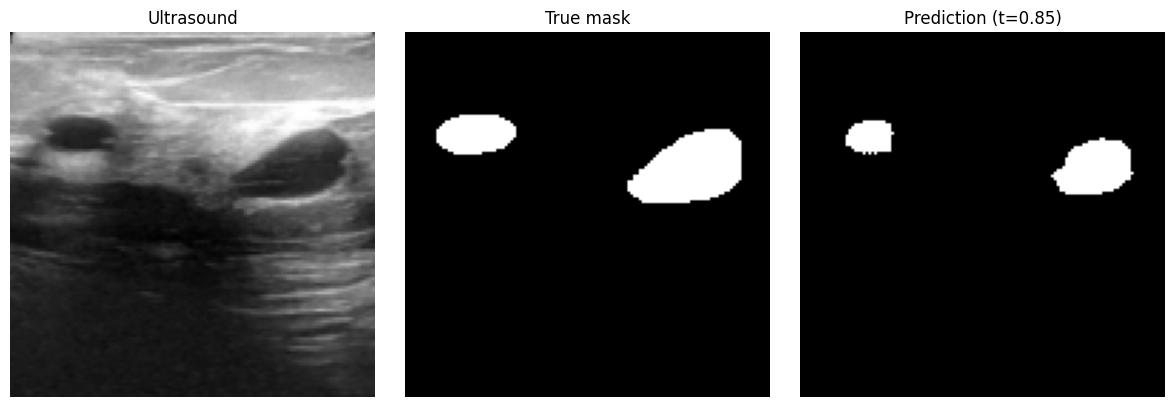

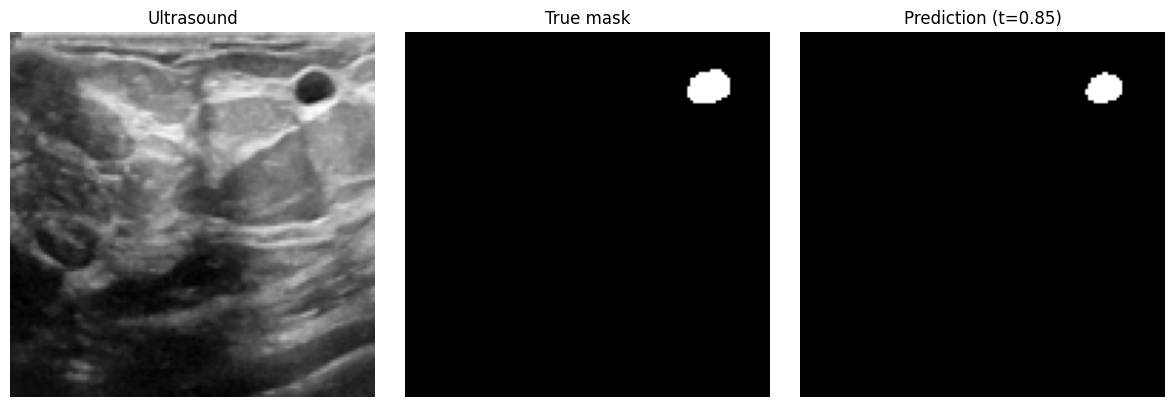

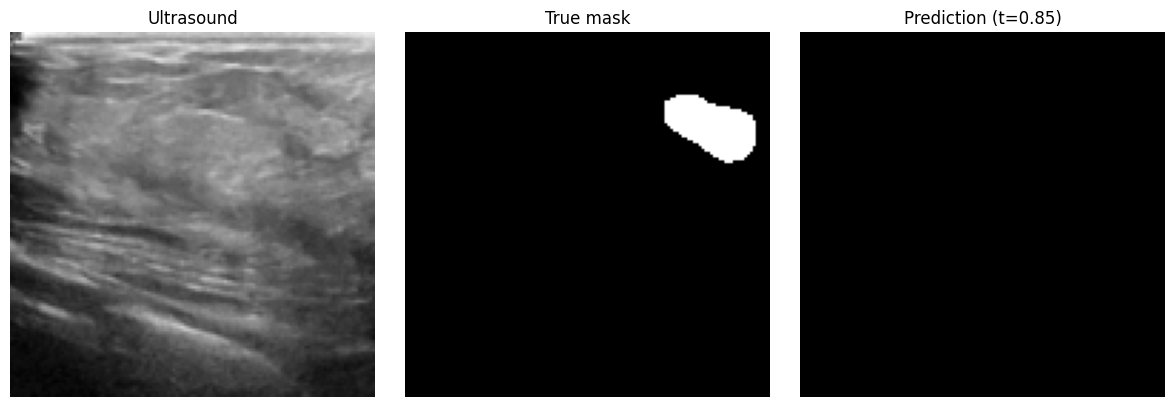

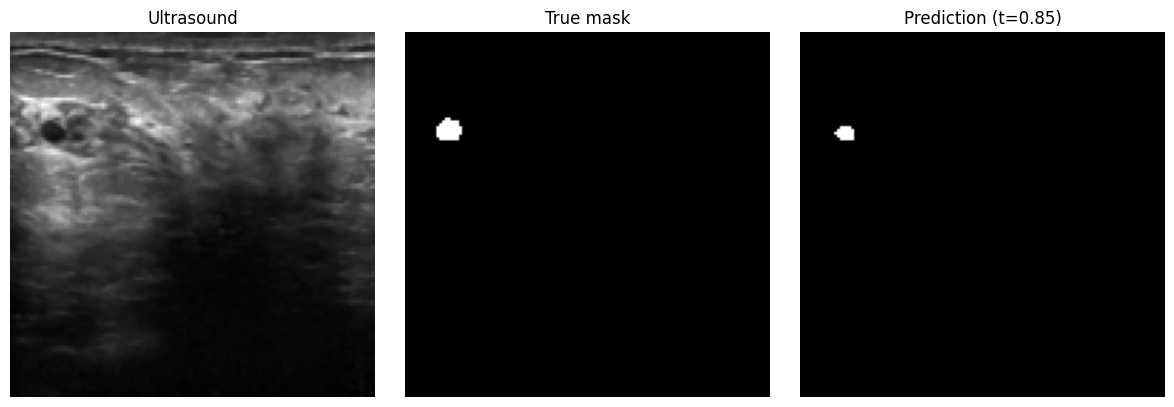

In [20]:

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

model.eval()
shown = 0
threshold = 0.85

with torch.no_grad():
    for x, y in val_loader:
        probs = torch.sigmoid(model(x.to(DEVICE))).cpu().numpy()
        images = x.numpy()
        masks = y.numpy()

        for i in range(len(images)):
            if shown >= 4:
                break

            image = images[i, 0]
            true_mask = masks[i, 0]
            pred_mask = (probs[i, 0] >= threshold).astype(np.uint8)

            fig, ax = plt.subplots(1, 3, figsize=(12, 4))
            ax[0].imshow(image, cmap="gray")
            ax[0].set_title("Ultrasound")
            ax[1].imshow(true_mask, cmap="gray")
            ax[1].set_title("True mask")
            ax[2].imshow(pred_mask, cmap="gray")
            ax[2].set_title(f"Prediction (t={threshold})")

            for a in ax:
                a.axis("off")

            plt.tight_layout()
            plt.show()
            shown += 1

        if shown >= 4:
            break

In [21]:

import os
import pandas as pd

DATA_ROOT = "/kaggle/input/competitions/skillntell-breast-cancer-v2"
sample = pd.read_csv(os.path.join(DATA_ROOT, "sample_submission.csv"))

print("Submission columns:")
print(sample.columns.tolist())

print("\nFirst 10 rows:")
print(sample.head(10).to_string(index=False))

print("\nRows per task prefix:")
print(sample.iloc[:, 0].astype(str).str.extract(r"^(S\d+)")[0].value_counts())

Submission columns:
['row_id', 'prediction']

First 10 rows:
               row_id         prediction
   S1_US316340_normal 0.3333333333333333
   S1_US316340_benign 0.3333333333333333
S1_US316340_malignant 0.3333333333333333
     S1_US316340_mask                   
   S1_USb5e95b_normal 0.3333333333333333
   S1_USb5e95b_benign 0.3333333333333333
S1_USb5e95b_malignant 0.3333333333333333
     S1_USb5e95b_mask                   
   S1_US7de6f6_normal 0.3333333333333333
   S1_US7de6f6_benign 0.3333333333333333

Rows per task prefix:
0
S1    1024
S3     633
Name: count, dtype: int64


In [22]:

import os
import pandas as pd
from PIL import Image

DATA_ROOT = "/kaggle/input/competitions/skillntell-breast-cancer-v2"
TEST_IMAGE_DIR = os.path.join(DATA_ROOT, "test", "stage1", "images")

sample = pd.read_csv(os.path.join(DATA_ROOT, "sample_submission.csv"))

mask_rows = sample[
    sample["row_id"].str.match(r"^S1_.+_mask$")
].copy()

mask_rows["image_id"] = (
    mask_rows["row_id"]
    .str.replace(r"^S1_", "", regex=True)
    .str.replace(r"_mask$", "", regex=True)
)

print("Stage 1 mask rows:", len(mask_rows))
print("\nFirst five test image IDs and dimensions:")

for image_id in mask_rows["image_id"].head(5):
    path = os.path.join(TEST_IMAGE_DIR, image_id + ".png")
    print(image_id, "exists:", os.path.exists(path))

    if os.path.exists(path):
        with Image.open(path) as img:
            print("  Original dimensions (width, height):", img.size)

Stage 1 mask rows: 256

First five test image IDs and dimensions:
US316340 exists: True
  Original dimensions (width, height): (485, 537)
USb5e95b exists: True
  Original dimensions (width, height): (761, 572)
US7de6f6 exists: True
  Original dimensions (width, height): (545, 532)
US169594 exists: True
  Original dimensions (width, height): (485, 537)
US597ca5 exists: True
  Original dimensions (width, height): (831, 538)


In [23]:

import os
import numpy as np
import pandas as pd
import torch
from PIL import Image

THRESHOLD = 0.85
OUTPUT_CSV = "/kaggle/working/submission_unet_candidate.csv"

def encode_rle(mask):
    # Column-major order, with runs represented as start length.
    pixels = mask.T.flatten().astype(np.uint8)
    padded = np.concatenate([[0], pixels, [0]])
    changes = np.where(padded[1:] != padded[:-1])[0] + 1
    changes[1::2] -= changes[::2]
    return " ".join(map(str, changes))

candidate = sample.copy()
mask_rows = candidate["row_id"].str.match(r"^S1_.+_mask$")

test_root = os.path.dirname(TEST_IMAGE_DIR)
test_mask_dir = os.path.join(test_root, "masks")

model.eval()
updated = 0

with torch.no_grad():
    for idx in candidate.index[mask_rows]:
        row_id = candidate.at[idx, "row_id"]
        image_id = row_id.removeprefix("S1_").removesuffix("_mask")

        image_path = os.path.join(TEST_IMAGE_DIR, image_id + ".png")
        image = Image.open(image_path).convert("L")
        original_size = image.size

        resized = image.resize(
            (SIZE, SIZE), Image.Resampling.BILINEAR
        )
        arr = np.array(resized, dtype=np.float32) / 255.0
        x = torch.from_numpy(arr[None, None]).to(DEVICE)

        prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
        small_mask = (prob >= THRESHOLD).astype(np.uint8)

        # Resize the binary mask back to the original dimensions.
        mask_img = Image.fromarray(small_mask * 255)
        full_mask = mask_img.resize(
            original_size, Image.Resampling.NEAREST
        )
        binary_mask = (np.array(full_mask) > 0).astype(np.uint8)

        candidate.at[idx, "prediction"] = encode_rle(binary_mask)
        updated += 1

candidate.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Masks updated:", updated)
print("Rows preserved:", len(candidate))
print("Missing predictions:", candidate["prediction"].isna().sum())
print("Empty encoded masks:",
      (candidate.loc[mask_rows, "prediction"] == "").sum())
print(candidate.loc[mask_rows, ["row_id", "prediction"]].head(3))

Saved: /kaggle/working/submission_unet_candidate.csv
Masks updated: 256
Rows preserved: 1657
Missing predictions: 0
Empty encoded masks: 155
              row_id                                         prediction
3   S1_US316340_mask                                                   
7   S1_USb5e95b_mask                                                   
11  S1_US7de6f6_mask  178928 4 179460 4 179992 4 180524 4 181056 4 1...


In [24]:

for name, obj in globals().copy().items():
    if callable(obj) and any(
        term in name.lower()
        for term in ["rle", "encode", "mask"]
    ):
        try:
            print(f"\n--- {name} ---")
            import inspect
            print(inspect.getsource(obj))
        except (OSError, TypeError):
            print("Source unavailable")


--- rle_encode ---
def rle_encode(mask):
    """Row-major order, 1-indexed starts: 'start length start length ...'; a single space for an empty mask (Kaggle rejects empty cells)."""
    flat = np.asarray(mask, bool).ravel(order="C").astype(np.int8)
    if not flat.any():
        return " "
    padded = np.concatenate([[0], flat, [0]])
    ch = np.flatnonzero(padded[1:] != padded[:-1]) + 1
    return " ".join(f"{s} {e - s}" for s, e in zip(ch[0::2], ch[1::2]))


--- lesion_mask ---
def lesion_mask(path, p_lesion, threshold=0.5):
    a = np.asarray(Image.open(path).convert("L"), np.float32)
    if p_lesion < threshold:
        return np.zeros(a.shape, bool)
    sm = ndimage.gaussian_filter(a, 3)
    h, w = a.shape
    centre = np.zeros(a.shape, bool)
    centre[h // 6: 5 * h // 6, w // 6: 5 * w // 6] = True
    cand = (sm <= np.percentile(sm[centre], 12)) & centre
    lab, n = ndimage.label(cand)
    if n == 0:
        return np.zeros(a.shape, bool)
    sizes = ndimage.sum(cand, lab, ra

In [25]:

# Use the baseline's exact RLE convention.
def encode_rle(mask):
    flat = np.asarray(mask, bool).ravel(order="C").astype(np.int8)

    if not flat.any():
        return " "

    padded = np.concatenate([[0], flat, [0]])
    ch = np.flatnonzero(padded[1:] != padded[:-1]) + 1

    return " ".join(
        f"{s} {e - s}"
        for s, e in zip(ch[0::2], ch[1::2])
    )


# Regenerate the candidate from the original sample submission.
candidate = sample.copy()
mask_rows = candidate["row_id"].str.match(r"^S1_.+_mask$")

model.eval()
updated = 0

with torch.no_grad():
    for idx in candidate.index[mask_rows]:
        row_id = candidate.at[idx, "row_id"]
        image_id = row_id.removeprefix("S1_").removesuffix("_mask")

        image_path = os.path.join(TEST_IMAGE_DIR, image_id + ".png")

        image = Image.open(image_path).convert("L")
        original_size = image.size

        resized = image.resize(
            (SIZE, SIZE), Image.Resampling.BILINEAR
        )
        arr = np.array(resized, dtype=np.float32) / 255.0
        x = torch.from_numpy(arr[None, None]).to(DEVICE)

        prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
        small_mask = (prob >= THRESHOLD).astype(np.uint8)

        full_mask = Image.fromarray(small_mask * 255).resize(
            original_size, Image.Resampling.NEAREST
        )
        binary_mask = np.array(full_mask) > 0

        candidate.at[idx, "prediction"] = encode_rle(binary_mask)
        updated += 1

OUTPUT_CSV = "/kaggle/working/submission_unet_candidate.csv"
candidate.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Masks updated:", updated)
print("Total rows:", len(candidate))
print("Missing predictions:", candidate["prediction"].isna().sum())
print("Empty masks:", (candidate.loc[mask_rows, "prediction"] == " ").sum())
print(candidate.loc[mask_rows, ["row_id", "prediction"]].head(3))

Saved: /kaggle/working/submission_unet_candidate.csv
Masks updated: 256
Total rows: 1657
Missing predictions: 0
Empty masks: 155
              row_id                                         prediction
3   S1_US316340_mask                                                   
7   S1_USb5e95b_mask                                                   
11  S1_US7de6f6_mask  90816 4 91361 4 91906 4 92451 4 92992 8 93537 ...


In [26]:

import pandas as pd
import numpy as np

BASELINE_PATH = "/kaggle/input/competitions/skillntell-breast-cancer-v2/sample_submission.csv"
CANDIDATE_PATH = "/kaggle/working/submission_unet_candidate.csv"

baseline = pd.read_csv(BASELINE_PATH, keep_default_na=False)
candidate_check = pd.read_csv(CANDIDATE_PATH, keep_default_na=False)

assert list(candidate_check.columns) == list(baseline.columns), "Column mismatch!"
assert len(candidate_check) == len(baseline) == 1657, "Row count mismatch!"
assert candidate_check["row_id"].equals(baseline["row_id"]), "Row order or IDs changed!"
assert not candidate_check["prediction"].isna().any(), "Missing predictions!"

mask_rows = candidate_check["row_id"].str.match(r"^S1_.+_mask$")
non_mask_rows = ~mask_rows

assert mask_rows.sum() == 256, "Unexpected mask row count!"
assert candidate_check.loc[non_mask_rows, "prediction"].equals(
    baseline.loc[non_mask_rows, "prediction"]
), "Non-mask predictions changed!"

print("PASS: columns and row count")
print("PASS: row IDs and order preserved")
print("PASS: all 256 mask rows present")
print("PASS: non-mask predictions unchanged")
print("Empty mask strings:", 
      (candidate_check.loc[mask_rows, "prediction"] == " ").sum())
print("Candidate ready for final review:", CANDIDATE_PATH)

PASS: columns and row count
PASS: row IDs and order preserved
PASS: all 256 mask rows present
PASS: non-mask predictions unchanged
Empty mask strings: 155
Candidate ready for final review: /kaggle/working/submission_unet_candidate.csv


In [27]:

from IPython.display import FileLink, display
import os

file_path = "/kaggle/working/submission_unet_candidate.csv"

if os.path.exists(file_path):
    print("File found!")
    print("Size:", round(os.path.getsize(file_path) / 1024, 2), "KB")
    display(FileLink(file_path))
else:
    print("File not found. Check the path.")

File found!
Size: 96.46 KB


/kaggle/working/submission_unet_candidate.csv

In [28]:

from IPython.display import HTML, display
from pathlib import Path
import base64

path = Path("/kaggle/working/submission_unet_candidate.csv")

if path.exists():
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    display(HTML(
        f'<a download="submission_unet_candidate.csv" '
        f'href="data:text/csv;base64,{encoded}">'
        f'Click here to download submission_unet_candidate.csv</a>'
    ))
    print("File size:", round(path.stat().st_size / 1024, 2), "KB")
else:
    print("Candidate file not found.")

File size: 96.46 KB


In [29]:

import os
import shutil
from IPython.display import display, FileLink

csv_path = "/kaggle/working/submission_unet_candidate.csv"
zip_path = "/kaggle/working/submission_unet_candidate.zip"

if os.path.exists(csv_path):
    shutil.make_archive(
        "/kaggle/working/submission_unet_candidate",
        "zip",
        root_dir="/kaggle/working",
        base_dir="submission_unet_candidate.csv"
    )
    print("ZIP created:", os.path.getsize(zip_path), "bytes")
    display(FileLink(zip_path))
else:
    print("CSV not found:", csv_path)

ZIP created: 28385 bytes


/kaggle/working/submission_unet_candidate.zip

In [30]:

import os
import pandas as pd

src = "/kaggle/working/submission_unet_candidate.csv"
dst = "/kaggle/working/submission.csv"

assert os.path.exists(src), f"File not found: {src}"

df = pd.read_csv(src, keep_default_na=False)
df.to_csv(dst, index=False)

print("Created:", dst)
print("Rows:", len(df))
print("Columns:", list(df.columns))
print("Size:", os.path.getsize(dst), "bytes")

Created: /kaggle/working/submission.csv
Rows: 1657
Columns: ['row_id', 'prediction']
Size: 98777 bytes
